In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import plotly.graph_objects as go

pio.templates.default = "plotly_white"

In [18]:
drivers_df = pd.read_csv('DRIVERS.csv')
vehicles_df = pd.read_csv('VEHICLES.csv')
tires_df = pd.read_csv('TIRES.csv')
gliders_df = pd.read_csv('GLIDERS.csv')

UFuncTypeError: ufunc 'greater_equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

C:\Users\lolo\AppData\Local\Temp\ipykernel_21288\238589755.py:123: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



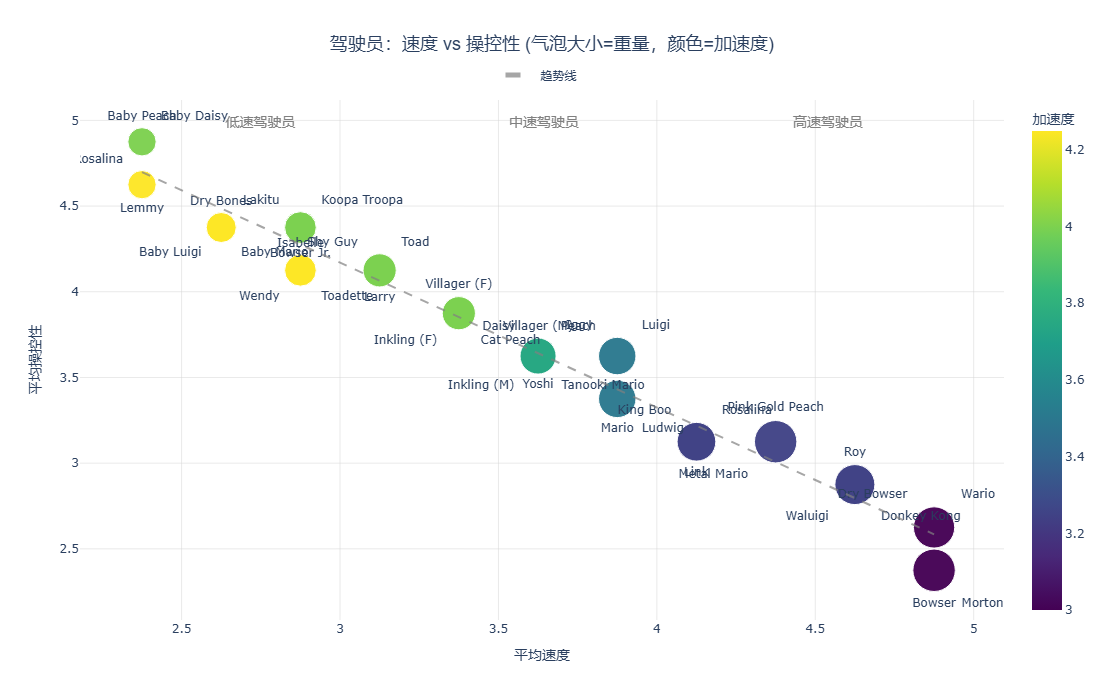

In [34]:
def create_improved_speed_handling_scatter(df, name_col, title):
    """
    创建改进的速度vs操控性散点图
    
    参数:
    df: 包含数据的DataFrame
    name_col: 包含实体名称的列
    title: 图表标题
    
    返回:
    plotly图表对象
    """
    # 计算平均速度和平均操控性
    df['AvgSpeed'] = df[['GroundSpeed', 'WaterSpeed', 'AirSpeed', 'AntiGravitySpeed']].mean(axis=1)
    df['AvgHandling'] = df[['GroundHandling', 'WaterHandling', 'AirHandling', 'AntiGravityHandling']].mean(axis=1)
    
    # 为了减少拥挤感，可以按照某种逻辑对驾驶员进行分类
    # 例如，按照平均速度将驾驶员分为不同类别
    df['SpeedCategory'] = pd.cut(df['AvgSpeed'], bins=3, labels=['低速', '中速', '高速'])
    
    # 创建改进的散点图
    fig = px.scatter(
        df, 
        x='AvgSpeed', 
        y='AvgHandling', 
        size='Weight', 
        color='Acceleration',
        text=name_col,
        hover_name=name_col,
        title=title,
        labels={
            'AvgSpeed': '平均速度',
            'AvgHandling': '平均操控性',
            'Weight': '重量',
            'Acceleration': '加速度'
        },
        color_continuous_scale='viridis',  # 更改颜色比例尺
        size_max=30,  # 控制最大气泡尺寸
        opacity=0.8,  # 添加一些透明度
        height=700,  # 增加图表高度
        width=900    # 增加图表宽度
    )
    
    # 更新布局
    fig.update_layout(
        xaxis_title=dict(
            text="平均速度",
            font=dict(size=14, family="Arial, sans-serif")
        ),
        yaxis_title=dict(
            text="平均操控性",
            font=dict(size=14, family="Arial, sans-serif")
        ),
        coloraxis_colorbar=dict(
            title=dict(
                text="加速度",
                font=dict(size=14, family="Arial, sans-serif")
            ),
            tickfont=dict(size=12)
        ),
        title=dict(
            text=title,
            font=dict(size=18, family="Arial, sans-serif"),
            x=0.5,
            xanchor='center'
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        ),
        margin=dict(l=80, r=80, t=100, b=80),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            showgrid=True,
            gridwidth=0.5,
            gridcolor='lightgray',
            zeroline=False
        ),
        yaxis=dict(
            showgrid=True,
            gridwidth=0.5,
            gridcolor='lightgray',
            zeroline=False
        )
    )
    
    # 智能调整文本标签位置，避免重叠
    # 基于数据点的分布自动计算最佳位置
    df_sorted = df.sort_values('AvgSpeed')
    positions = ['top center', 'top right', 'top left', 'bottom center', 'bottom right', 'bottom left']
    
    # 创建文本位置映射
    text_positions = {}
    for i, row in df_sorted.iterrows():
        idx = i % len(positions)
        text_positions[row[name_col]] = positions[idx]
    
    # 为每个点分配不同的文本位置
    for i, trace in enumerate(fig.data):
        fig.data[i].textposition = [text_positions.get(name, 'top center') for name in df[name_col]]
    
    # 添加趋势线以显示速度和操控性的反比关系
    x_range = np.linspace(df['AvgSpeed'].min(), df['AvgSpeed'].max(), 100)
    z = np.polyfit(df['AvgSpeed'], df['AvgHandling'], 1)
    p = np.poly1d(z)
    
    fig.add_trace(
        go.Scatter(
            x=x_range,
            y=p(x_range),
            mode='lines',
            line=dict(color='rgba(128, 128, 128, 0.7)', width=2, dash='dash'),
            name='趋势线',
            showlegend=True
        )
    )
    
    # 添加驾驶员类别的注释
    categories = df.groupby('SpeedCategory')['AvgSpeed'].mean().to_dict()
    
    for category, avg_x in categories.items():
        fig.add_annotation(
            x=avg_x,
            y=df['AvgHandling'].max(),
            text=category + "驾驶员",
            showarrow=False,
            font=dict(size=14, color="gray"),
            yshift=20
        )
    
    return fig

improved_scatter = create_improved_speed_handling_scatter(
     drivers_df, 
     'Driver', 
     '驾驶员：速度 vs 操控性 (气泡大小=重量，颜色=加速度)'
)
improved_scatter.show()

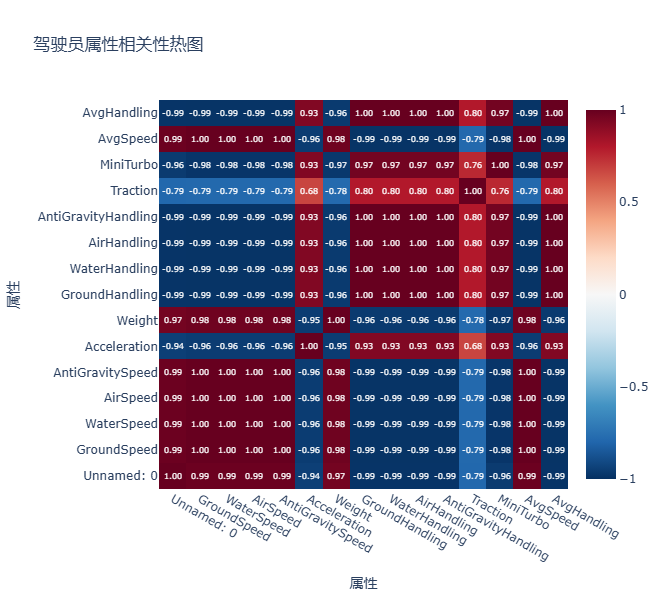

In [23]:
def create_attribute_heatmap(df, name_col, title):

    attribute_cols = df.columns.tolist()
    attribute_cols.remove(name_col)
    
    corr = df[attribute_cols].corr()

    fig = go.Figure(data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.index,
        colorscale='RdBu_r',
        zmid=0,
        text=np.round(corr.values, 2),
        texttemplate='%{text:.2f}'
    ))
    
    fig.update_layout(
        title=title,
        xaxis_title="属性",
        yaxis_title="属性",
        height=600,
        width=700
    )
    
    return fig

heatmap_drivers = create_attribute_heatmap(
    drivers_df, 
    'Driver', 
    '驾驶员属性相关性热图'
)
heatmap_drivers.show()

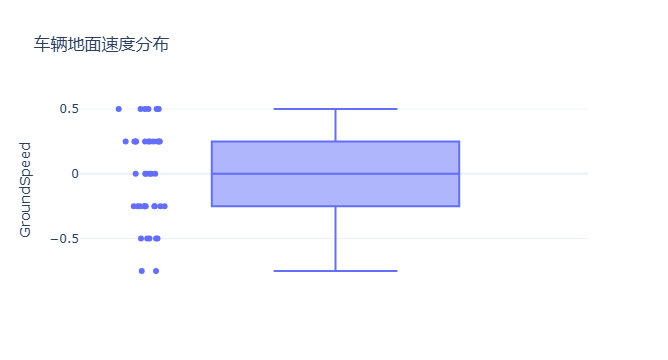

In [24]:
def create_boxplots(df, name_col, attribute, title):
    fig = px.box(
        df, 
        y=attribute, 
        points="all", 
        hover_name=name_col,
        title=title
    )
    
    fig.update_layout(
        xaxis_title="",
        yaxis_title=attribute
    )
    
    return fig

boxplot_vehicles_speed = create_boxplots(
    vehicles_df, 
    'Vehicle', 
    'GroundSpeed', 
    '车辆地面速度分布'
)
boxplot_vehicles_speed.show()

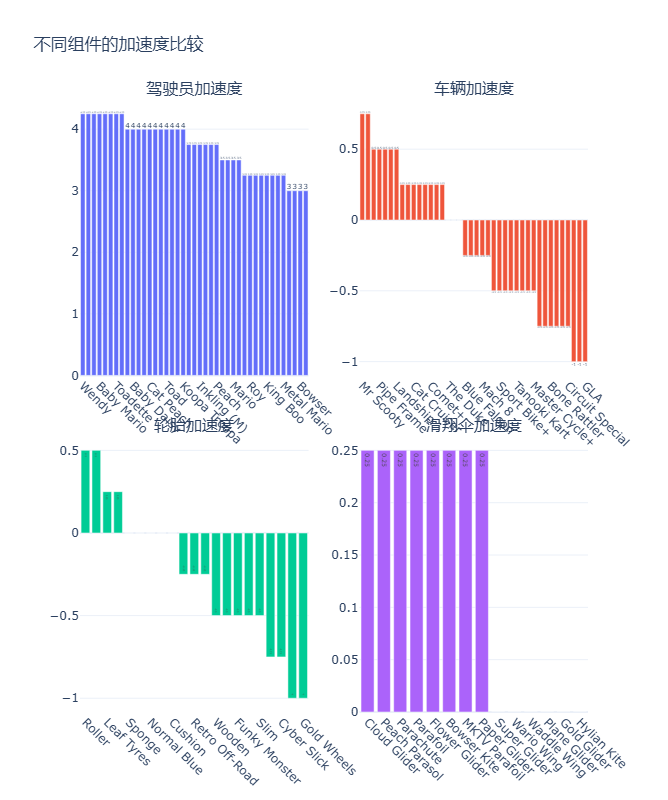

In [25]:
def create_component_comparison(dfs, name_cols, attribute, titles, main_title):
    
    fig = make_subplots(
        rows=2, 
        cols=2,
        subplot_titles=titles,
        vertical_spacing=0.1,
        horizontal_spacing=0.1
    )

    for i, (df, name_col) in enumerate(zip(dfs, name_cols)):
        row, col = i // 2 + 1, i % 2 + 1
        
        sorted_df = df.sort_values(attribute, ascending=False)
        
        fig.add_trace(
            go.Bar(
                x=sorted_df[name_col],
                y=sorted_df[attribute],
                name=titles[i],
                text=sorted_df[attribute].round(2),
                textposition='auto'
            ),
            row=row, col=col
        )
    
    fig.update_layout(
        title=main_title,
        showlegend=False,
        height=800,
        width=1000
    )
    
    fig.update_xaxes(tickangle=45)
    
    return fig
    
component_comparison = create_component_comparison(
    [drivers_df, vehicles_df, tires_df, gliders_df],
    ['Driver', 'Vehicle', 'Tire', 'Glider'],
    'Acceleration',
    ['驾驶员加速度', '车辆加速度', '轮胎加速度', '滑翔伞加速度'],
    '不同组件的加速度比较'
)
component_comparison.show()

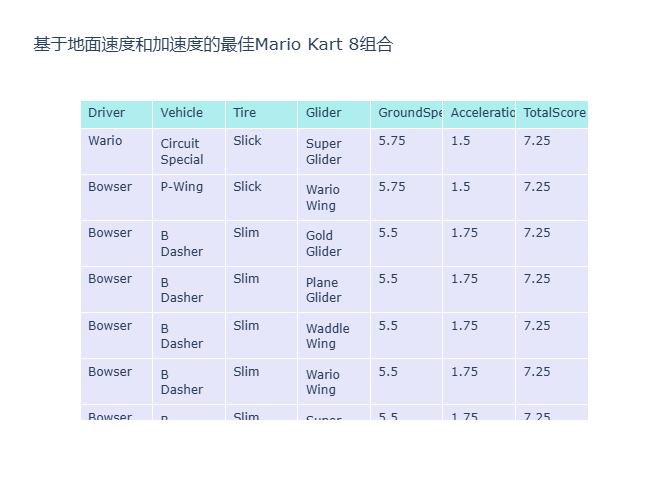

In [26]:
def find_best_combinations(drivers_df, vehicles_df, tires_df, gliders_df, 
                           attributes=['GroundSpeed', 'Acceleration'], top_n=10):
    
    top_drivers = drivers_df.nlargest(5, attributes[0])
    top_vehicles = vehicles_df.nlargest(5, attributes[0])
    top_tires = tires_df.nlargest(5, attributes[0])
    top_gliders = gliders_df.nlargest(5, attributes[0])

    combinations = []
    
    for _, driver in top_drivers.iterrows():
        for _, vehicle in top_vehicles.iterrows():
            for _, tire in top_tires.iterrows():
                for _, glider in top_gliders.iterrows():
                    
                    combo_attrs = {}
                    for attr in attributes:
                        combo_attrs[attr] = driver[attr] + vehicle[attr] + tire[attr] + glider[attr]
                    
                    combo = {
                        'Driver': driver['Driver'],
                        'Vehicle': vehicle['Vehicle'],
                        'Tire': tire['Tire'],
                        'Glider': glider['Glider']
                    }
                    
                    for attr in attributes:
                        combo[attr] = combo_attrs[attr]
                    
                    combinations.append(combo)
    
    combos_df = pd.DataFrame(combinations)
    
    combos_df['TotalScore'] = combos_df[attributes].sum(axis=1)

    return combos_df.sort_values('TotalScore', ascending=False).head(top_n)

best_combos = find_best_combinations(
    drivers_df, vehicles_df, tires_df, gliders_df,
    attributes=['GroundSpeed', 'Acceleration'], 
    top_n=10
)


def plot_best_combinations(combos_df, title):
    
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=list(combos_df.columns),
            fill_color='paleturquoise',
            align='left'
        ),
        cells=dict(
            values=[combos_df[col] for col in combos_df.columns],
            fill_color='lavender',
            align='left'
        )
    )])
    
    fig.update_layout(
        title=title,
        height=500,
        width=1000
    )
    
    return fig

best_combos_table = plot_best_combinations(
    best_combos, 
    '基于地面速度和加速度的最佳Mario Kart 8组合'
)
best_combos_table.show()

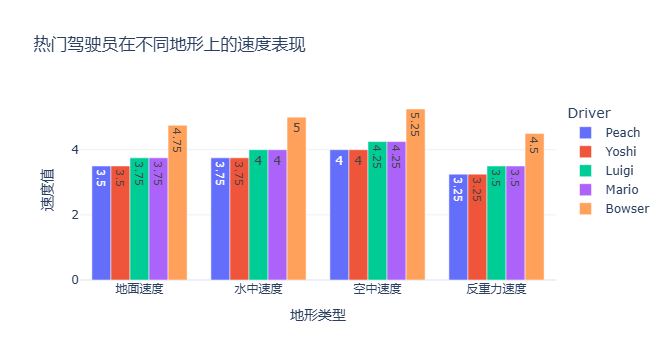

In [27]:
def create_terrain_performance(df, name_col, entities, title):
    
    terrain_cols = ['GroundSpeed', 'WaterSpeed', 'AirSpeed', 'AntiGravitySpeed']

    filtered_df = df[df[name_col].isin(entities)]

    fig = go.Figure()
    
    for _, row in filtered_df.iterrows():
        entity_name = row[name_col]
        values = [row[col] for col in terrain_cols]
        
        fig.add_trace(go.Bar(
            x=terrain_cols,
            y=values,
            name=entity_name,
            text=np.round(values, 2),
            textposition='auto'
        ))
    

    fig.update_layout(
        title=title,
        xaxis_title="地形类型",
        yaxis_title="速度值",
        legend_title=name_col,
        barmode='group'
    )
    
    terrain_labels = ['地面速度', '水中速度', '空中速度', '反重力速度']
    fig.update_xaxes(ticktext=terrain_labels, tickvals=terrain_cols)
    
    return fig

terrain_performance = create_terrain_performance(
    drivers_df,
    'Driver',
    ['Mario', 'Luigi', 'Peach', 'Bowser', 'Yoshi'],
    '热门驾驶员在不同地形上的速度表现'
)
terrain_performance.show()

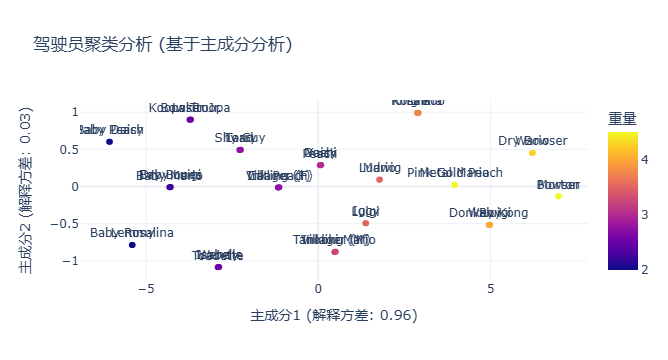

In [28]:
def create_driver_clustering(df, name_col):
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    feature_cols = df.columns.tolist()
    feature_cols.remove(name_col)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[feature_cols])
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
    pca_df[name_col] = df[name_col].values
    
    pca_df['Weight'] = df['Weight'].values
    
    fig = px.scatter(
        pca_df, 
        x='PC1', 
        y='PC2', 
        color='Weight',
        hover_name=name_col,
        text=name_col,
        title='驾驶员聚类分析 (基于主成分分析)'
    )
    
    fig.update_layout(
        xaxis_title=f"主成分1 (解释方差: {pca.explained_variance_ratio_[0]:.2f})",
        yaxis_title=f"主成分2 (解释方差: {pca.explained_variance_ratio_[1]:.2f})",
        coloraxis_colorbar_title="重量"
    )
    
    fig.update_traces(textposition='top center')
    
    return fig

driver_clustering = create_driver_clustering(drivers_df, 'Driver')
driver_clustering.show()

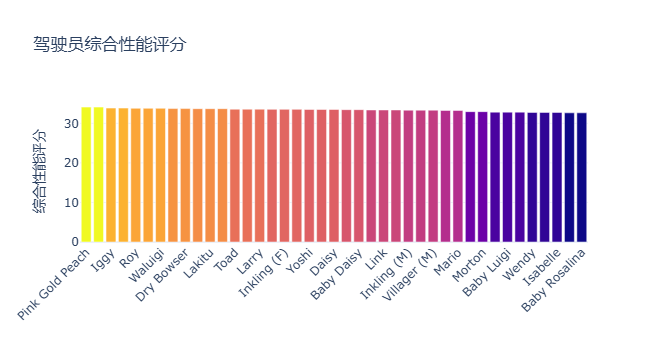

In [29]:
def create_performance_scores(df, name_col, title):
    # 定义各项属性的权重（可以根据实际需求调整）
    weights = {
        'GroundSpeed': 1.0,
        'WaterSpeed': 0.8,
        'AirSpeed': 0.8,
        'AntiGravitySpeed': 0.8,
        'Acceleration': 1.0,
        'Weight': 0.5,
        'GroundHandling': 0.9,
        'WaterHandling': 0.7,
        'AirHandling': 0.7,
        'AntiGravityHandling': 0.7,
        'Traction': 0.6,
        'MiniTurbo': 0.8
    }
    
    # 创建一个副本以避免修改原始数据
    temp_df = df.copy()
    
    # 计算加权分数
    temp_df['WeightedScore'] = 0
    for attr, weight in weights.items():
        if attr in temp_df.columns:
            temp_df['WeightedScore'] += temp_df[attr] * weight
    
    # 按加权分数排序
    sorted_df = temp_df.sort_values('WeightedScore', ascending=False)
    
    # 创建条形图
    fig = px.bar(
        sorted_df,
        x=name_col,
        y='WeightedScore',
        color='WeightedScore',
        labels={name_col: '', 'WeightedScore': '综合性能评分'},
        title=title,
        hover_data=list(weights.keys())
    )
    
    # 更新布局
    fig.update_layout(
        xaxis_tickangle=-45,
        coloraxis_showscale=False
    )
    
    return fig

# 创建驾驶员综合性能评分图
driver_performance = create_performance_scores(
    drivers_df, 
    'Driver', 
    '驾驶员综合性能评分'
)
driver_performance.show()

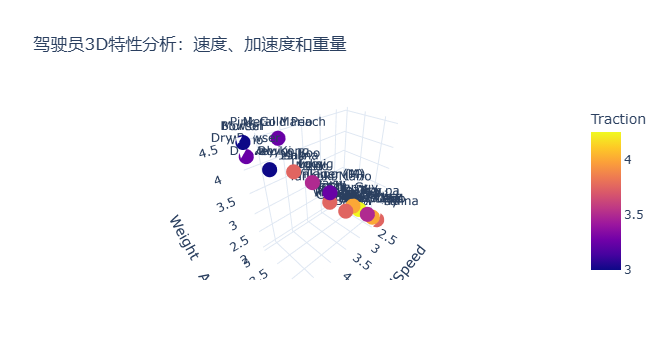

In [30]:
def create_3d_scatter(df, name_col, x_attr, y_attr, z_attr, color_attr, title):
    fig = px.scatter_3d(
        df, 
        x=x_attr,
        y=y_attr,
        z=z_attr,
        color=color_attr,
        hover_name=name_col,
        text=name_col,
        title=title,
        labels={
            x_attr: x_attr,
            y_attr: y_attr,
            z_attr: z_attr,
            color_attr: color_attr
        }
    )
    
    # 更新布局
    fig.update_layout(
        scene=dict(
            xaxis_title=x_attr,
            yaxis_title=y_attr,
            zaxis_title=z_attr
        ),
        coloraxis_colorbar_title=color_attr
    )
    
    return fig

# 创建3D散点图，分析速度、加速度和重量之间的关系
scatter_3d = create_3d_scatter(
    drivers_df,
    'Driver',
    'GroundSpeed',
    'Acceleration',
    'Weight',
    'Traction',
    '驾驶员3D特性分析：速度、加速度和重量'
)
scatter_3d.show()